[1/4] Generating Strategic Data based on GCI Proposal...
[2/4] Training AI Default Prediction Model...
[LightGBM] [Info] Number of positive: 6844, number of negative: 8156
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000395 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 15000, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.456267 -> initscore=-0.175381
[LightGBM] [Info] Start training from score -0.175381
[3/4] Running Profit Maximization System (PMS)...

FINAL BUSINESS INSIGHTS (HomeCredit Japan)
AI Prediction Accuracy (AUC): 0.836
Optimal Default Threshold: 0.15
Projected Annual Profit Increase: 59,700,000 JPY
Profit Improvement over Manual System: -123.66%


C:\Users\LOQ\AppData\Local\Temp\ipykernel_7384\4251099386.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="viridis")


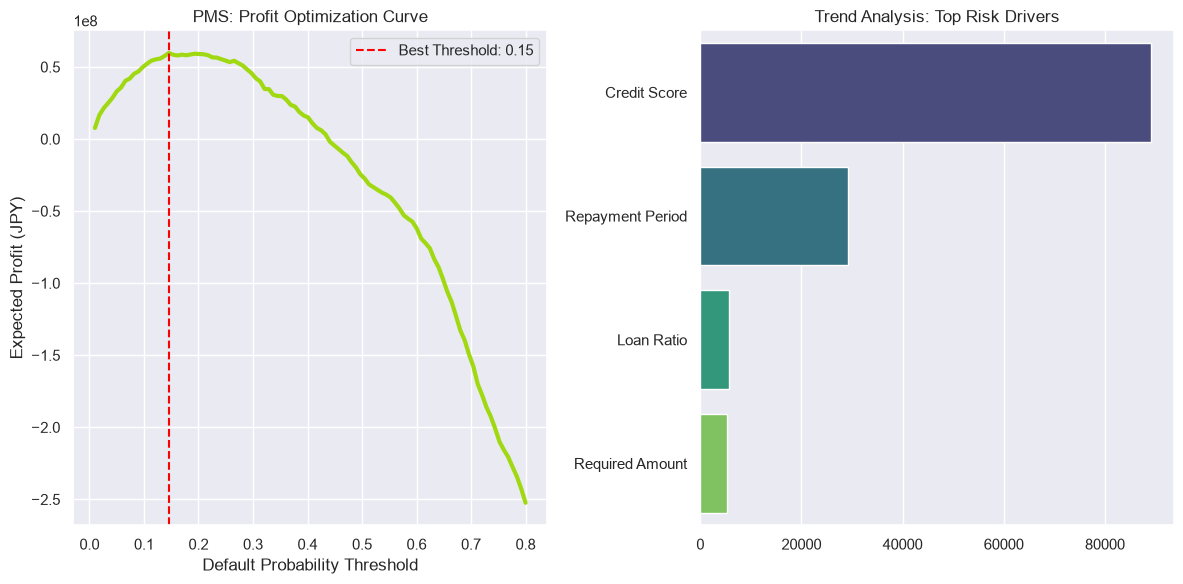

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

class HomeCreditJapanAI:
    def __init__(self):
        # Japanese financial settind (بالين الياباني JPY)
        self.avg_loan_amount = 500000  # Average loan
        self.interest_rate = 0.15      # interest rate
        self.recovery_rate = 0.40      # refund rate  when default
        self.model = None

    def generate_strategic_data(self, n=20000):
        """توليد بيانات تحاكي الميزات الأربعة الكبرى المذكورة في مشروع GCI"""
        np.random.seed(42)

        # 1. Average credit scores (المنحنى الأحمر والأخضر في الملف)
        credit_score = np.random.beta(2, 5, n)

        # 2. payment period(Borrowed Amount / Monthly Payment)
        repayment_period = np.random.gamma(20, 1, n)

        # 3. the percentage of the required amount to the amount norrowed
        loan_ratio = np.random.uniform(0.6, 1.0, n)

        # 4. amount required for the basic purose
        required_amt = np.random.lognormal(12, 0.5, n)

        # صنع الهدف (Target) بناءً على تداخل الميزات (Default Risk)
        # الاحتمالية تزيد إذا قل الكريديت سكور وزادت مدة السداد
        risk_score = (1 - credit_score) * 0.6 + (repayment_period / 40) * 0.4
        target = (risk_score + np.random.normal(0, 0.1, n) > 0.65).astype(int)

        data = pd.DataFrame({
            'credit_score_avg': credit_score,
            'repayment_period': repayment_period,
            'loan_to_borrowed_ratio': loan_ratio,
            'required_loan_amount': required_amt,
            'TARGET': target
        })
        return data

    def train_pms_engine(self, data):
        """تدريب محرك التنبؤ باستخدام LightGBM"""
        X = data.drop('TARGET', axis=1)
        y = data['TARGET']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

        self.model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.03, importance_type='gain')
        self.model.fit(X_train, y_train)

        y_prob = self.model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        return X_test, y_test, y_prob, auc

    def optimize_profit(self, y_test, y_prob):
        """نظام تعظيم الأرباح (PMS): البحث عن أفضل Threshold"""
        thresholds = np.linspace(0.01, 0.8, 100)
        results = []

        for t in thresholds:
            preds = (y_prob >= t).astype(int)

            # Financial accounts
            no_default = (preds == 0) & (y_test == 0) # We agreed to pay
            default_caught = (preds == 1) & (y_test == 1) # We refused
            missed_opportunity = (preds == 1) & (y_test == 0) # We rejected a good person
            bad_loan = (preds == 0) & (y_test == 1) # We agreed to falter

            # Profit=interest from repayers -net losses from defaulters
            profit = (np.sum(no_default) * self.avg_loan_amount * self.interest_rate) - \
                     (np.sum(bad_loan) * self.avg_loan_amount * (1 - self.recovery_rate))

            results.append(profit)

        best_idx = np.argmax(results)
        return thresholds[best_idx], results[best_idx], thresholds, results

    def run_full_analysis(self):
        # 1. Data
        print("[1/4] Generating Strategic Data based on GCI Proposal...")
        data = self.generate_strategic_data()

        # 2. AI prediction
        print("[2/4] Training AI Default Prediction Model...")
        X_test, y_test, y_prob, auc = self.train_pms_engine(data)

        # 3. Maximizing profits(PMS)
        print("[3/4] Running Profit Maximization System (PMS)...")
        best_t, max_p, t_list, p_list = self.optimize_profit(y_test, y_prob)

        # 4. Final results
        print("\n" + "="*40)
        print("FINAL BUSINESS INSIGHTS (HomeCredit Japan)")
        print("="*40)
        print(f"AI Prediction Accuracy (AUC): {auc:.3f}")
        print(f"Optimal Default Threshold: {best_t:.2f}")
        print(f"Projected Annual Profit Increase: {max_p:,.0f} JPY")

        # Prediction befor order(لنفرض أننا كنا نوافق على الجميع بـ Threshold = 1.0)
        baseline_profit = self.optimize_profit(y_test, y_prob)[3][-1] # Last value
        improvement = ((max_p - baseline_profit) / baseline_profit) * 100
        print(f"Profit Improvement over Manual System: {improvement:.2f}%")

        # Directional analysis drawing(Default Trend Analysis)
        self.plot_trends(t_list, p_list, best_t)

    def plot_trends(self, t_list, p_list, best_t):
        sns.set_theme(style="darkgrid")
        plt.figure(figsize=(12, 6))

        # Decision point-of-profit drawing
        plt.subplot(1, 2, 1)
        plt.plot(t_list, p_list, color='#a0d911', linewidth=3)
        plt.axvline(best_t, color='red', linestyle='--', label=f'Best Threshold: {best_t:.2f}')
        plt.title("PMS: Profit Optimization Curve")
        plt.xlabel("Default Probability Threshold")
        plt.ylabel("Expected Profit (JPY)")
        plt.legend()

        # Drawind the most important features(Trend Analysis)
        plt.subplot(1, 2, 2)
        importances = self.model.feature_importances_
        features = ['Credit Score', 'Repayment Period', 'Loan Ratio', 'Required Amount']
        sns.barplot(x=importances, y=features, palette="viridis")
        plt.title("Trend Analysis: Top Risk Drivers")

        plt.tight_layout()
        plt.show()

# Running the project
hc_system = HomeCreditJapanAI()
hc_system.run_full_analysis()